# Setup ENIGMA TOOLBOX Dataset

```
# Source: ENIGMA Toolbox docs – Installation
# https://enigma-toolbox.readthedocs.io/en/latest/pages/01.install/index.html

# Initialize ENIGMA Submodule
git submodule update --init --recursive

# Install ENIGMA Dependcies
cd ENIGMA
python setup.py install
```

# HCP Dataset Visualization

This notebook visualizes the Human Connectome Project (HCP) dataset using the **ENIGMA Toolbox**.

Sections:
1. **Dataset Visualization** – Load and inspect HCP structural/functional connectivity matrices
2. **Cortical Surface Visualization** – Map parcellated data onto the `fsa5` cortical surface
3. **Subcortical Surface Visualization** – Project subcortical metrics onto subcortical structures

Reference: [ENIGMA Toolbox Surface Visualization](https://enigma-toolbox.readthedocs.io/en/latest/pages/12.visualization/index.html#surf-visualization)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from enigmatoolbox.datasets import load_sc, load_fc, load_summary_stats
from enigmatoolbox.utils.parcellation import parcel_to_surface
from enigmatoolbox.plotting import plot_cortical, plot_subcortical

%matplotlib inline
print('Imports successful.')

Imports successful.


---
## Section 1: Dataset Visualization

Load and inspect three HCP structural connectivity (SC) matrices from the ENIGMA Toolbox:

| Matrix | Variable | Shape | Description |
|---|---|---|---|
| Cortical–Cortical | `sc_ctx` | 68 × 68 | SC between cortical regions (Desikan-Killiany atlas) |
| Subcortical–Cortical | `sc_sctx` | 14 × 68 | SC from each subcortical structure to each cortical region |
| Combined (ctx + sctx) | `sc_combined` | 82 × 82 | Full block-assembled matrix (symmetric) |

In [2]:
# ── Load SC data ───────────────────────────────────────────────────────────────
# load_sc() returns:
#   sc_ctx       – cortical–cortical        (68 × 68)
#   sc_ctx_labels – cortical region names   (68,)
#   sc_sctx      – subcortical–cortical cross-block (14 × 68)
#   sc_sctx_labels – subcortical region names (14,)
sc_ctx, sc_ctx_labels, sc_sctx, sc_sctx_labels = load_sc()

n_ctx  = sc_ctx.shape[0]   # 68
n_sctx = sc_sctx.shape[0]  # 14

# ── 1. Cortical–Cortical matrix ───────────────────────────────────────────────
print('=== Cortical–Cortical SC (68 × 68) ===')
print('  Shape      :', sc_ctx.shape)
print('  Non-zero   :', np.count_nonzero(sc_ctx))
print('  Min / Max  :', round(sc_ctx.min(), 4), '/', round(sc_ctx.max(), 4))
print('  Labels (first 5):', sc_ctx_labels[:5])

# ── 2. Subcortical–Cortical cross-block matrix ────────────────────────────────
print('\n=== Subcortical–Cortical SC (14 × 68) ===')
print('  Shape      :', sc_sctx.shape)
print('  Non-zero   :', np.count_nonzero(sc_sctx))
print('  Min / Max  :', round(sc_sctx.min(), 4), '/', round(sc_sctx.max(), 4))
print('  Subcortical labels:', sc_sctx_labels)

# ── 3. Combined block-assembled matrix (82 × 82) ──────────────────────────────
# Layout:
#   [ sc_ctx   (68×68)  |  sc_sctx.T  (68×14) ]
#   [ sc_sctx  (14×68)  |  zeros      (14×14) ]  ← sctx–sctx not provided
sc_combined = np.zeros((n_ctx + n_sctx, n_ctx + n_sctx))
sc_combined[:n_ctx,  :n_ctx]  = sc_ctx          # cortical–cortical
sc_combined[n_ctx:,  :n_ctx]  = sc_sctx         # subcortical–cortical
sc_combined[:n_ctx,  n_ctx:]  = sc_sctx.T       # cortical–subcortical (symmetric)
combined_labels = list(sc_ctx_labels) + list(sc_sctx_labels)

print('\n=== Combined SC (82 × 82) ===')
print('  Shape      :', sc_combined.shape)
print('  Non-zero   :', np.count_nonzero(sc_combined))
print('  Min / Max  :', round(sc_combined.min(), 4), '/', round(sc_combined.max(), 4))
print('  Total regions:', len(combined_labels))

=== Cortical–Cortical SC (68 × 68) ===
  Shape      : (68, 68)
  Non-zero   : 1394
  Min / Max  : 0.0 / 12.615
  Labels (first 5): ['L_bankssts' 'L_caudalanteriorcingulate' 'L_caudalmiddlefrontal'
 'L_cuneus' 'L_entorhinal']

=== Subcortical–Cortical SC (14 × 68) ===
  Shape      : (14, 68)
  Non-zero   : 417
  Min / Max  : 0.0 / 11.1634
  Subcortical labels: ['Laccumb' 'Lamyg' 'Lcaud' 'Lhippo' 'Lpal' 'Lput' 'Lthal' 'Raccumb'
 'Ramyg' 'Rcaud' 'Rhippo' 'Rpal' 'Rput' 'Rthal']

=== Combined SC (82 × 82) ===
  Shape      : (82, 82)
  Non-zero   : 2228
  Min / Max  : 0.0 / 12.615
  Total regions: 82


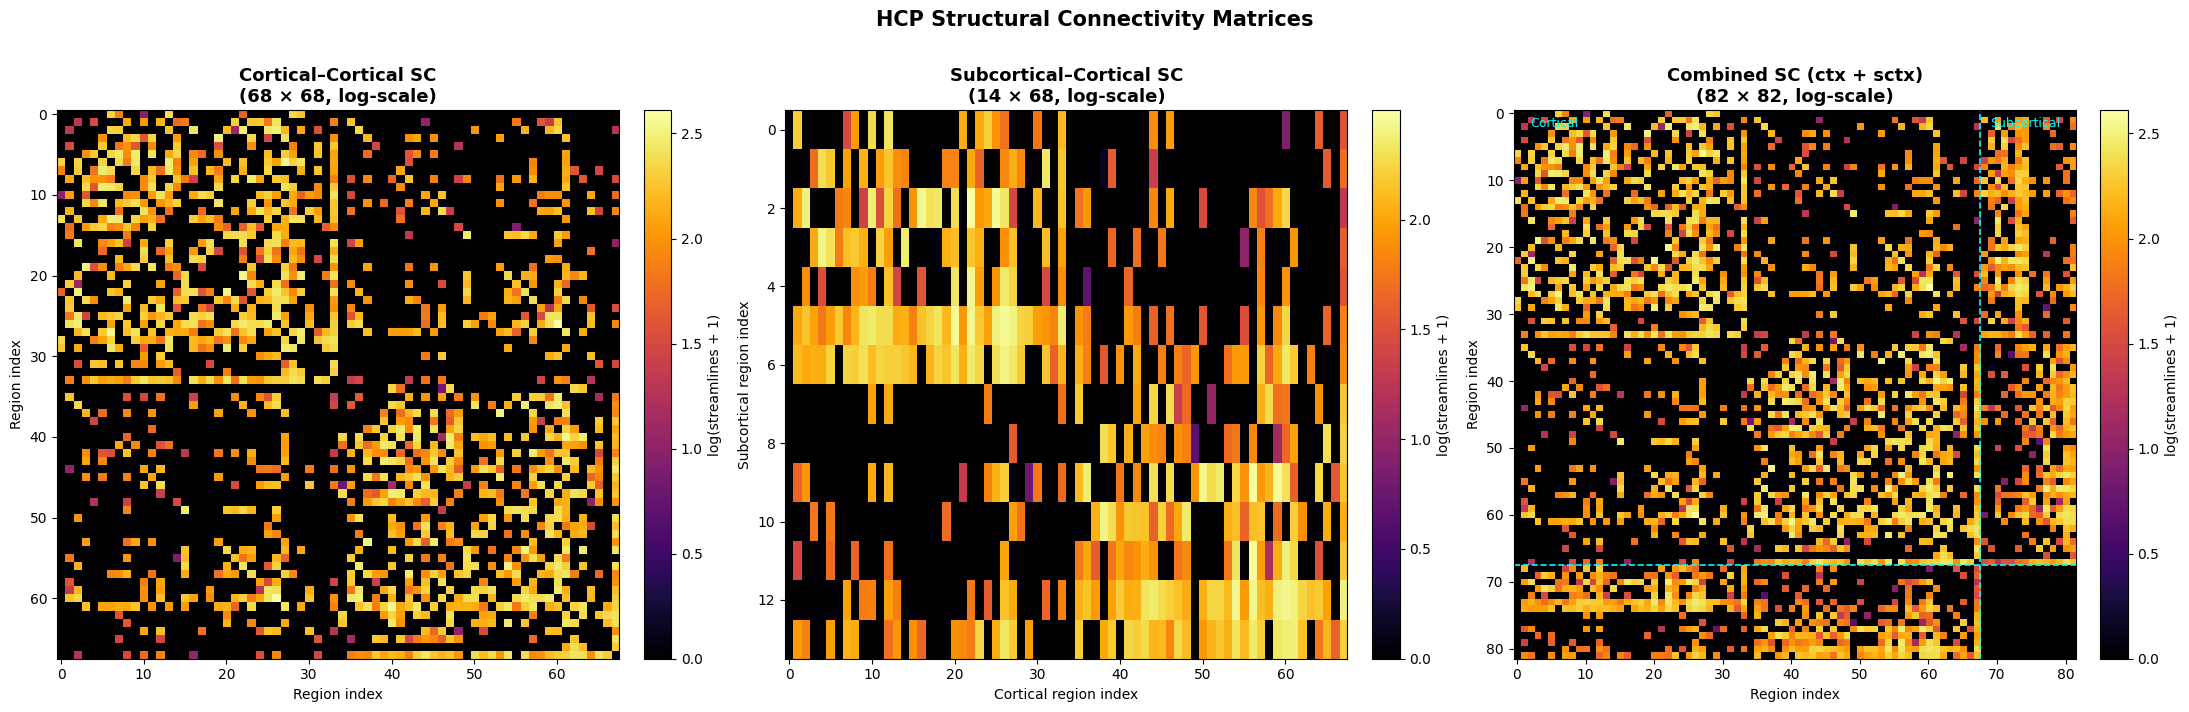

In [3]:
# ── Visualize all three SC matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

matrices = [
    (np.log1p(sc_ctx),      'Cortical–Cortical SC\n(68 × 68, log-scale)',         'inferno'),
    (np.log1p(sc_sctx),     'Subcortical–Cortical SC\n(14 × 68, log-scale)',       'inferno'),
    (np.log1p(sc_combined), 'Combined SC (ctx + sctx)\n(82 × 82, log-scale)',      'inferno'),
]

for ax, (mat, title, cmap) in zip(axes, matrices):
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Region index')
    ax.set_ylabel('Region index')
    plt.colorbar(im, ax=ax, label='log(streamlines + 1)', fraction=0.046, pad=0.04)

# Draw dividing line on the combined matrix to mark ctx/sctx boundary
axes[2].axhline(n_ctx - 0.5, color='cyan', linewidth=1.2, linestyle='--')
axes[2].axvline(n_ctx - 0.5, color='cyan', linewidth=1.2, linestyle='--')
axes[2].text(n_ctx + 1, 2, 'Subcortical', color='cyan', fontsize=9)
axes[2].text(2, 2, 'Cortical', color='cyan', fontsize=9)

# Label axes of the cross-block plot
axes[1].set_ylabel('Subcortical region index')
axes[1].set_xlabel('Cortical region index')

plt.suptitle('HCP Structural Connectivity Matrices', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hcp_sc_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Network density     : 0.306  (697 / 2278 edges present)
Weight range        : [1.24, 12.62]
Mean weight         : 7.41
Median weight       : 7.52
Std weight          : 2.17


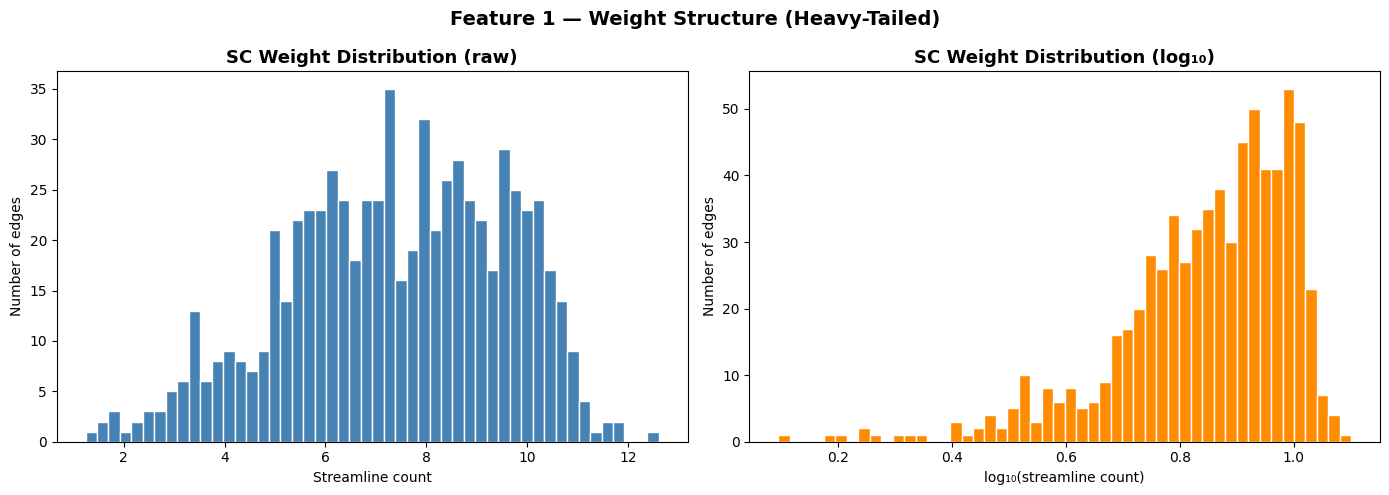

In [4]:
# ── Feature 1: Weight distribution & sparsity ────────────────────────────────
n = sc_ctx.shape[0]
total_possible = n * (n - 1) / 2          # upper triangle (undirected)
upper = sc_ctx[np.triu_indices(n, k=1)]
nonzero_weights = upper[upper > 0]

density = len(nonzero_weights) / total_possible

print(f'Network density     : {density:.3f}  ({len(nonzero_weights)} / {int(total_possible)} edges present)')
print(f'Weight range        : [{nonzero_weights.min():.2f}, {nonzero_weights.max():.2f}]')
print(f'Mean weight         : {nonzero_weights.mean():.2f}')
print(f'Median weight       : {np.median(nonzero_weights):.2f}')
print(f'Std weight          : {nonzero_weights.std():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw weight histogram
axes[0].hist(nonzero_weights, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SC Weight Distribution (raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Streamline count')
axes[0].set_ylabel('Number of edges')

# Log-weight histogram — shows approximate log-normality
axes[1].hist(np.log10(nonzero_weights), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('SC Weight Distribution (log₁₀)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log₁₀(streamline count)')
axes[1].set_ylabel('Number of edges')

plt.suptitle('Feature 1 — Weight Structure (Heavy-Tailed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 hub regions by SC strength:
                Region   Strength
    R_superiorparietal 330.349200
     R_superiorfrontal 292.341783
     L_superiorfrontal 283.113538
    L_superiorparietal 282.764606
              R_insula 276.256582
              L_insula 273.817865
           R_precuneus 233.596712
L_rostralmiddlefrontal 231.765033
           L_precuneus 218.888459
R_rostralmiddlefrontal 203.635933


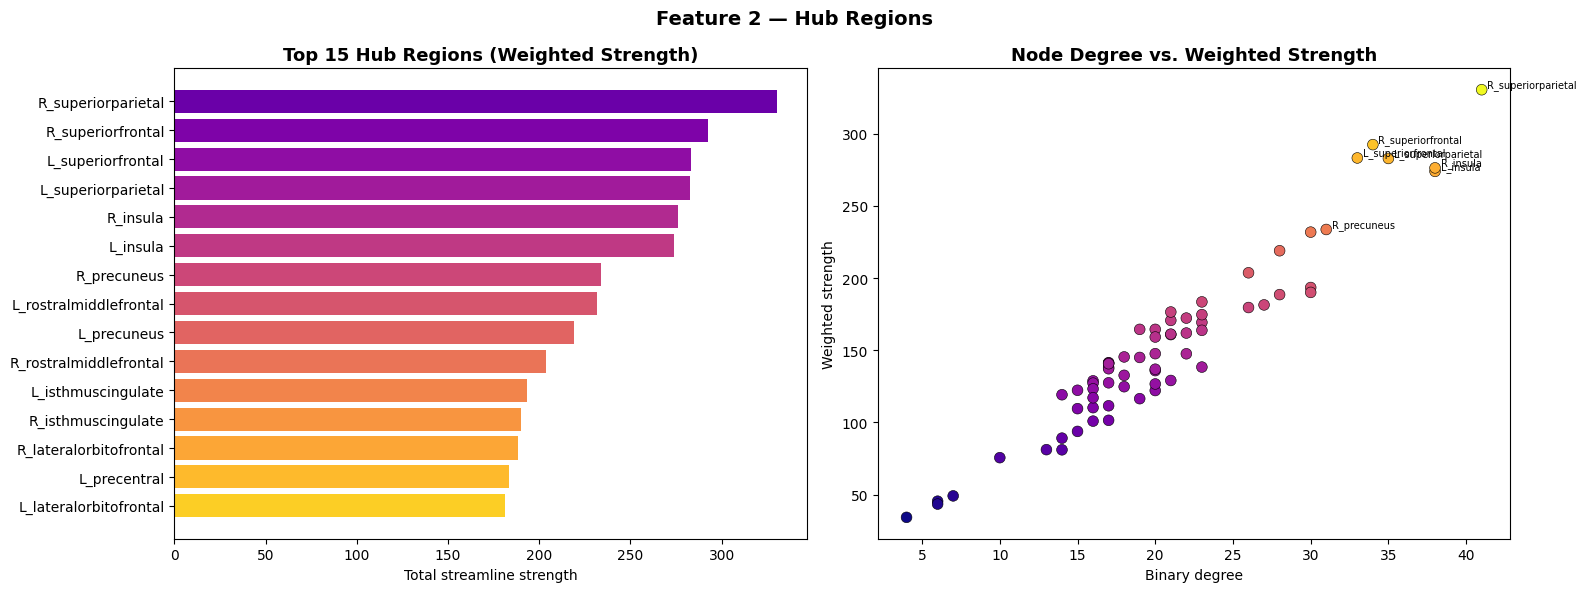

In [5]:
# ── Feature 2: Hub regions (top nodes by weighted strength) ──────────────────
# Weighted strength = sum of edge weights per node
sc_strength = sc_ctx.sum(axis=1)

# Rank and display top 10 hubs
hub_df = pd.DataFrame({'Region': sc_ctx_labels, 'Strength': sc_strength})
hub_df = hub_df.sort_values('Strength', ascending=False).reset_index(drop=True)

print('Top 10 hub regions by SC strength:')
print(hub_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart – top 15 hubs
top15 = hub_df.head(15)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, 15))
axes[0].barh(top15['Region'][::-1], top15['Strength'][::-1], color=colors[::-1])
axes[0].set_title('Top 15 Hub Regions (Weighted Strength)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total streamline strength')

# Scatter – degree vs strength (weighted vs binary)
sc_bin_degree = (sc_ctx > 0).sum(axis=1)
axes[1].scatter(sc_bin_degree, sc_strength, c=sc_strength, cmap='plasma', s=60, edgecolors='k', linewidths=0.4)
for i, label in enumerate(sc_ctx_labels):
    if sc_strength[i] > np.percentile(sc_strength, 90):
        axes[1].annotate(label, (sc_bin_degree[i], sc_strength[i]),
                         fontsize=7, xytext=(4, 2), textcoords='offset points')
axes[1].set_title('Node Degree vs. Weighted Strength', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Binary degree')
axes[1].set_ylabel('Weighted strength')

plt.suptitle('Feature 2 — Hub Regions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Left–Right strength correlation: r = 0.9535


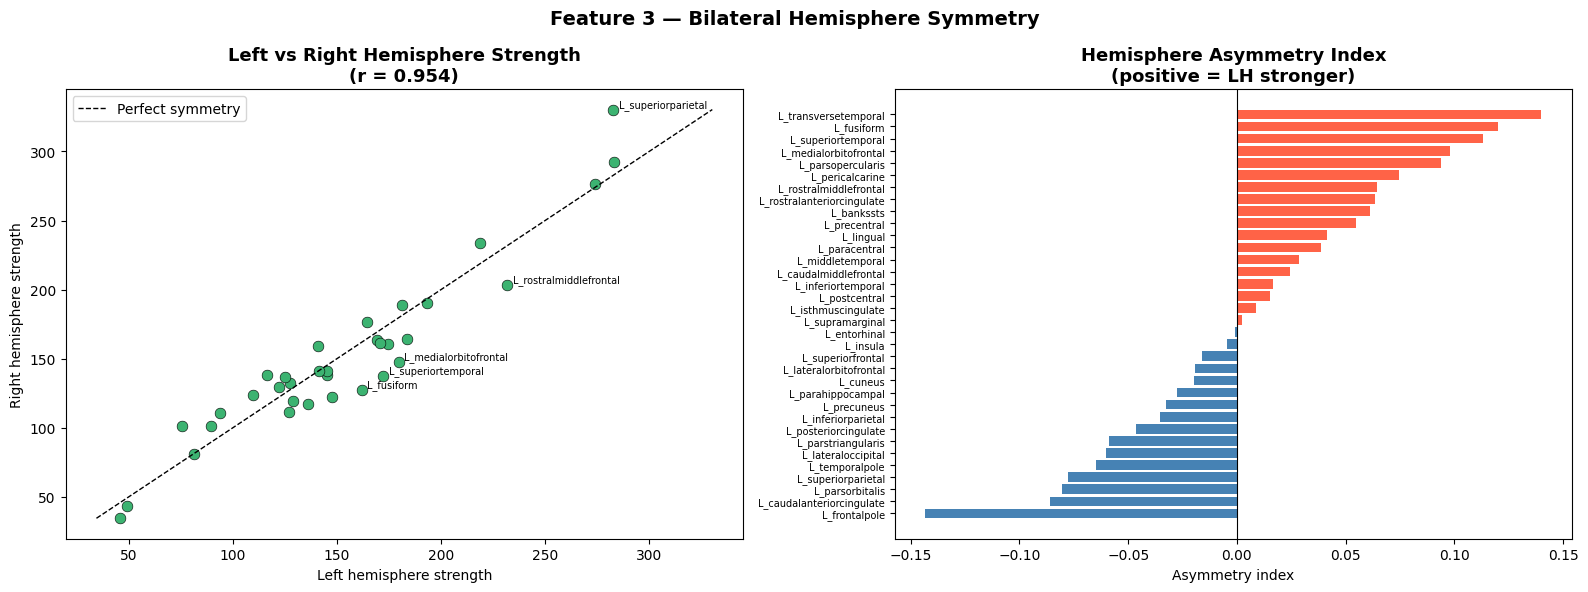

In [6]:
# ── Feature 3: Bilateral hemisphere symmetry ──────────────────────────────────
# Desikan-Killiany labels: lh_* (indices 0-33) and rh_* (indices 34-67)
n_hemi = n_ctx // 2
lh_strength = sc_strength[:n_hemi]
rh_strength = sc_strength[n_hemi:]
lh_labels   = [l.replace('lh_', '') for l in sc_ctx_labels[:n_hemi]]

corr_lr = np.corrcoef(lh_strength, rh_strength)[0, 1]
print(f'Left–Right strength correlation: r = {corr_lr:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter LH vs RH strength
axes[0].scatter(lh_strength, rh_strength, c='mediumseagreen', s=60, edgecolors='k', linewidths=0.4)
for i, lbl in enumerate(lh_labels):
    if abs(lh_strength[i] - rh_strength[i]) > np.std(lh_strength - rh_strength) * 1.5:
        axes[0].annotate(lbl, (lh_strength[i], rh_strength[i]), fontsize=7,
                         xytext=(4, 2), textcoords='offset points')
lims = [min(lh_strength.min(), rh_strength.min()), max(lh_strength.max(), rh_strength.max())]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Perfect symmetry')
axes[0].set_title(f'Left vs Right Hemisphere Strength\n(r = {corr_lr:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Left hemisphere strength')
axes[0].set_ylabel('Right hemisphere strength')
axes[0].legend()

# Asymmetry index per region
asymmetry = (lh_strength - rh_strength) / (lh_strength + rh_strength + 1e-9)
sorted_idx = np.argsort(asymmetry)
axes[1].barh(np.array(lh_labels)[sorted_idx], asymmetry[sorted_idx],
             color=['tomato' if a > 0 else 'steelblue' for a in asymmetry[sorted_idx]])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Hemisphere Asymmetry Index\n(positive = LH stronger)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Asymmetry index')
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('Feature 3 — Bilateral Hemisphere Symmetry', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_24754/2359224191.py:42: RuntimeWarning: Mean of empty slice
  rc_norm = rc_coeff / np.nanmean(rc_null, axis=0)   # normalized RC
/tmp/ipykernel_24754/2359224191.py:42: RuntimeWarning: divide by zero encountered in divide
  rc_norm = rc_coeff / np.nanmean(rc_null, axis=0)   # normalized RC
/home/yuchen/codespace/projects/school/SYDE532_Project/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


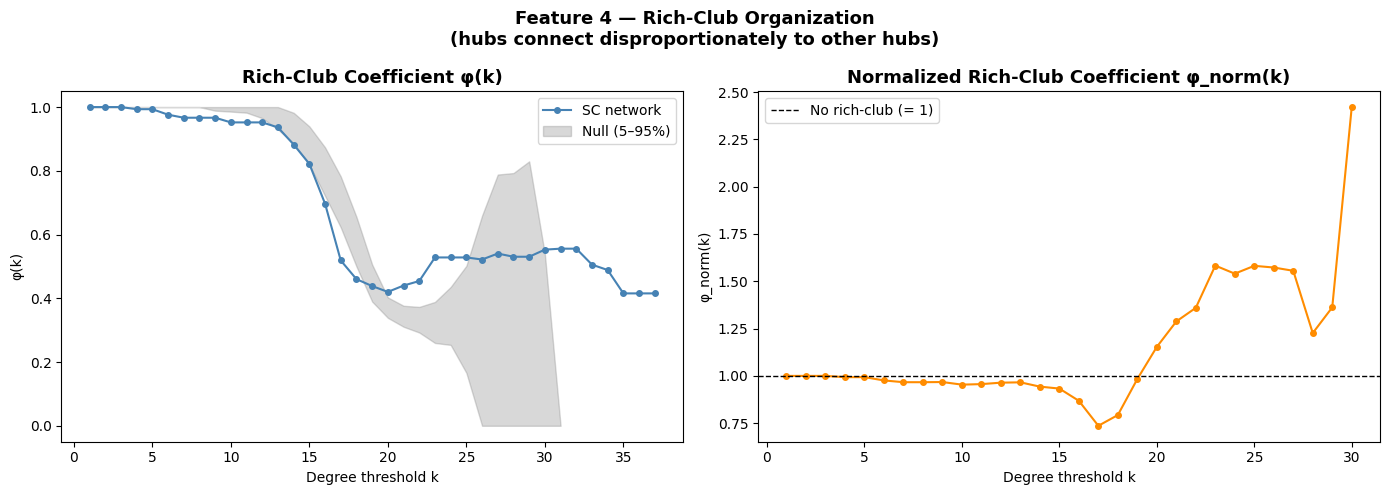

In [7]:
# ── Feature 4: Rich-club organization ─────────────────────────────────────────
# Rich-club: high-degree nodes preferentially interconnect with each other.
# RC coefficient φ(k) = (edges among nodes with degree > k) /
#                       (max possible edges among those nodes)

def rich_club_coefficient(W, k_levels=None):
    """Weighted rich-club coefficient across degree thresholds."""
    deg = (W > 0).sum(axis=1)
    if k_levels is None:
        k_levels = np.arange(1, deg.max())
    rc = []
    for k in k_levels:
        nodes_k = np.where(deg > k)[0]
        if len(nodes_k) < 2:
            rc.append(np.nan)
            continue
        sub = W[np.ix_(nodes_k, nodes_k)]
        actual   = sub.sum()
        # max possible: sort all weights in network descending, take top m
        m = len(nodes_k) * (len(nodes_k) - 1)    # directed count for upper+lower
        all_w = W[np.triu_indices(len(W), k=1)]
        all_w_sorted = np.sort(all_w[all_w > 0])[::-1]
        max_w = all_w_sorted[:m // 2].sum() * 2   # symmetric
        rc.append(actual / max_w if max_w > 0 else np.nan)
    return k_levels, np.array(rc)

k_levels, rc_coeff = rich_club_coefficient(sc_ctx)

# Null model: shuffle weights 100x and compute RC
np.random.seed(42)
rc_null = []
upper_idx = np.triu_indices(n_ctx, k=1)
for _ in range(100):
    W_null = np.zeros_like(sc_ctx)
    shuffled = sc_ctx[upper_idx].copy()
    np.random.shuffle(shuffled)
    W_null[upper_idx] = shuffled
    W_null = W_null + W_null.T
    _, rc_rand = rich_club_coefficient(W_null, k_levels)
    rc_null.append(rc_rand)
rc_null = np.array(rc_null)
rc_norm = rc_coeff / np.nanmean(rc_null, axis=0)   # normalized RC

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw RC
axes[0].plot(k_levels, rc_coeff, 'o-', color='steelblue', markersize=4, label='SC network')
axes[0].fill_between(k_levels,
                     np.nanpercentile(rc_null, 5, axis=0),
                     np.nanpercentile(rc_null, 95, axis=0),
                     alpha=0.3, color='gray', label='Null (5–95%)')
axes[0].set_title('Rich-Club Coefficient φ(k)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Degree threshold k')
axes[0].set_ylabel('φ(k)')
axes[0].legend()

# Normalized RC — values > 1 confirm rich-club
axes[1].plot(k_levels, rc_norm, 'o-', color='darkorange', markersize=4)
axes[1].axhline(1.0, color='k', linestyle='--', linewidth=1, label='No rich-club (= 1)')
axes[1].set_title('Normalized Rich-Club Coefficient φ_norm(k)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Degree threshold k')
axes[1].set_ylabel('φ_norm(k)')
axes[1].legend()

plt.suptitle('Feature 4 — Rich-Club Organization\n(hubs connect disproportionately to other hubs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

SC–FC edge correlation: r = 0.3601, p = 1.11e-70


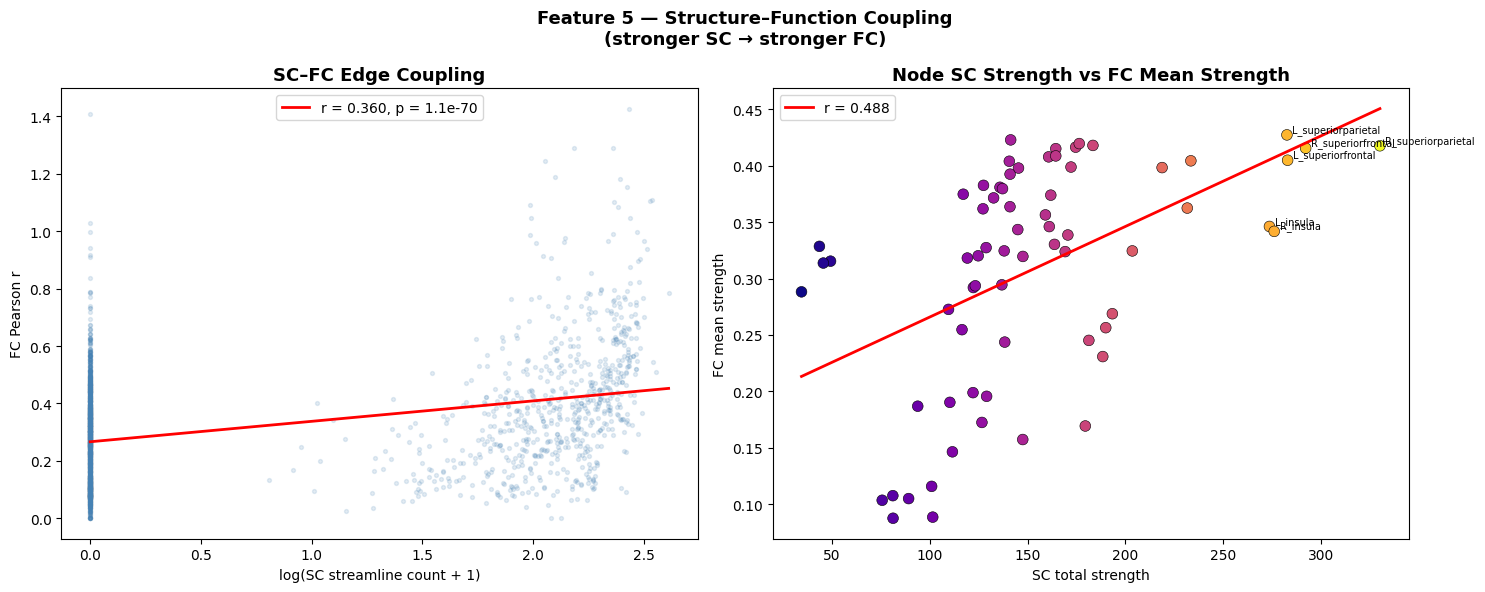

In [8]:
# ── Feature 5: Structure–Function coupling ────────────────────────────────────
# SC edges predict FC edges: regions strongly structurally connected tend to
# also show correlated BOLD signals. This SC–FC correlation is a key finding
# in connectomics research.

fc_ctx, fc_ctx_labels, fc_sctx, fc_sctx_labels = load_fc()

# Extract upper-triangle edges (undirected, no self-loops)
triu = np.triu_indices(n_ctx, k=1)
sc_edges = sc_ctx[triu]
fc_edges = fc_ctx[triu]

# Pearson correlation between SC and FC edge weights
from scipy import stats
r, p = stats.pearsonr(np.log1p(sc_edges), fc_edges)
print(f'SC–FC edge correlation: r = {r:.4f}, p = {p:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot: log(SC) vs FC
axes[0].scatter(np.log1p(sc_edges), fc_edges, alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(np.log1p(sc_edges), fc_edges, 1)
x_line = np.linspace(np.log1p(sc_edges).min(), np.log1p(sc_edges).max(), 100)
axes[0].plot(x_line, m * x_line + b, 'r-', linewidth=2, label=f'r = {r:.3f}, p = {p:.1e}')
axes[0].set_title('SC–FC Edge Coupling', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log(SC streamline count + 1)')
axes[0].set_ylabel('FC Pearson r')
axes[0].legend()

# Node-level: SC strength vs FC mean strength
sc_node_strength = sc_ctx.sum(axis=1)
fc_node_strength = fc_ctx.mean(axis=1)
r_node, p_node = stats.pearsonr(sc_node_strength, fc_node_strength)

axes[1].scatter(sc_node_strength, fc_node_strength, c=sc_node_strength,
                cmap='plasma', s=60, edgecolors='k', linewidths=0.4)
for i, lbl in enumerate(sc_ctx_labels):
    if sc_node_strength[i] > np.percentile(sc_node_strength, 92):
        axes[1].annotate(lbl, (sc_node_strength[i], fc_node_strength[i]),
                         fontsize=7, xytext=(4, 2), textcoords='offset points')
m2, b2 = np.polyfit(sc_node_strength, fc_node_strength, 1)
x2 = np.linspace(sc_node_strength.min(), sc_node_strength.max(), 100)
axes[1].plot(x2, m2 * x2 + b2, 'r-', linewidth=2, label=f'r = {r_node:.3f}')
axes[1].set_title('Node SC Strength vs FC Mean Strength', fontsize=13, fontweight='bold')
axes[1].set_xlabel('SC total strength')
axes[1].set_ylabel('FC mean strength')
axes[1].legend()

plt.suptitle('Feature 5 — Structure–Function Coupling\n(stronger SC → stronger FC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

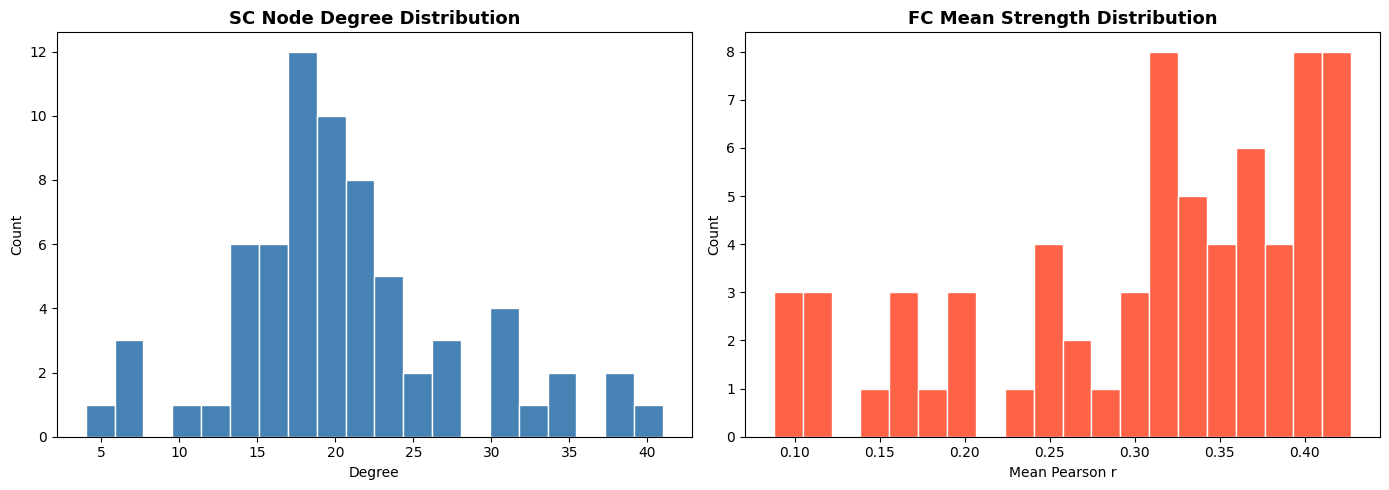

In [9]:
# ── Node-degree and FC strength distributions ─────────────────────────────────
sc_degree  = (sc_ctx > 0).sum(axis=1)          # binary degree
fc_strength = fc_ctx.mean(axis=1)               # mean FC per node

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sc_degree, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('SC Node Degree Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

axes[1].hist(fc_strength, bins=20, color='tomato', edgecolor='white')
axes[1].set_title('FC Mean Strength Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Pearson r')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('hcp_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2: Cortical Surface Visualization

We use `parcel_to_surface` to map parcellated (ROI-level) data onto the `fsa5` fsaverage5 surface, then render it with `plot_cortical`.

Images are rendered **offscreen** and embedded directly into the notebook.

Here we visualize:
- **SC node degree** mapped onto the cortical surface
- **FC mean strength** mapped onto the cortical surface
- **Cortical thickness** effect sizes (schizophrenia case vs control)

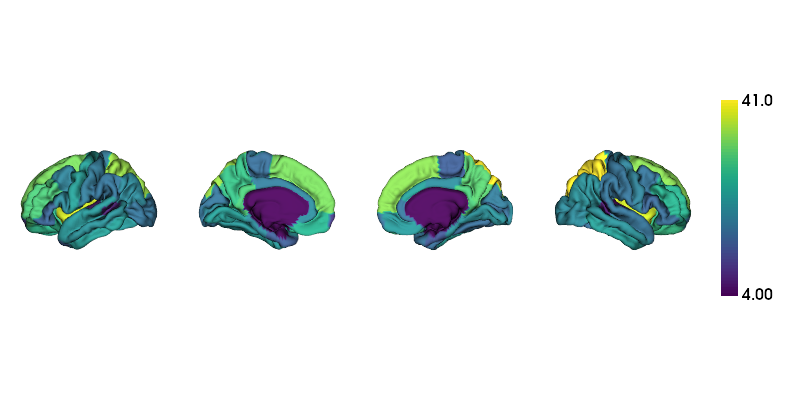

In [10]:
import os
from IPython.display import Image, display

# Force offscreen rendering (required on WSL / headless environments)
os.environ['VTK_DEFAULT_RENDER_WINDOW_TYPE'] = 'OSMesa'

# ── SC node degree on cortical surface ────────────────────────────────────────
sc_degree = (sc_ctx > 0).sum(axis=1)
sc_degree_fsa5 = parcel_to_surface(sc_degree, 'aparc_fsa5')

plot_cortical(
    array_name=sc_degree_fsa5,
    surface_name='fsa5',
    size=(800, 400),
    cmap='viridis',
    color_bar=True,
    color_range=(int(sc_degree.min()), int(sc_degree.max())),
    screenshot=True,
    filename='cortical_sc_degree.png',
)
display(Image('cortical_sc_degree.png'))

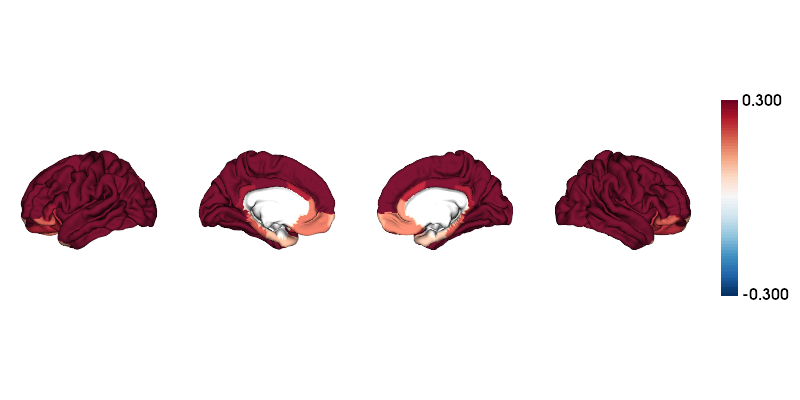

In [11]:
# ── FC mean strength on cortical surface ──────────────────────────────────────
fc_ctx, fc_ctx_labels, fc_sctx, fc_sctx_labels = load_fc()
fc_strength = fc_ctx.mean(axis=1)
fc_strength_fsa5 = parcel_to_surface(fc_strength, 'aparc_fsa5')

plot_cortical(
    array_name=fc_strength_fsa5,
    surface_name='fsa5',
    size=(800, 400),
    cmap='RdBu_r',
    color_bar=True,
    color_range=(-0.3, 0.3),
    screenshot=True,
    filename='cortical_fc_strength.png',
)
display(Image('cortical_fc_strength.png'))

---
## Section 3: Subcortical Surface Visualization

`plot_subcortical` directly accepts parcellated subcortical arrays (16 regions) — no prior `parcel_to_surface` step needed.

Subcortical FC strength: {np.str_('Laccumb'): np.float64(0.025), np.str_('Lamyg'): np.float64(0.063), np.str_('Lcaud'): np.float64(0.129), np.str_('Lhippo'): np.float64(0.152), np.str_('Lpal'): np.float64(0.037), np.str_('Lput'): np.float64(0.127), np.str_('Lthal'): np.float64(0.16), np.str_('Raccumb'): np.float64(0.026), np.str_('Ramyg'): np.float64(0.059), np.str_('Rcaud'): np.float64(0.121), np.str_('Rhippo'): np.float64(0.153), np.str_('Rpal'): np.float64(0.044), np.str_('Rput'): np.float64(0.13), np.str_('Rthal'): np.float64(0.155)}


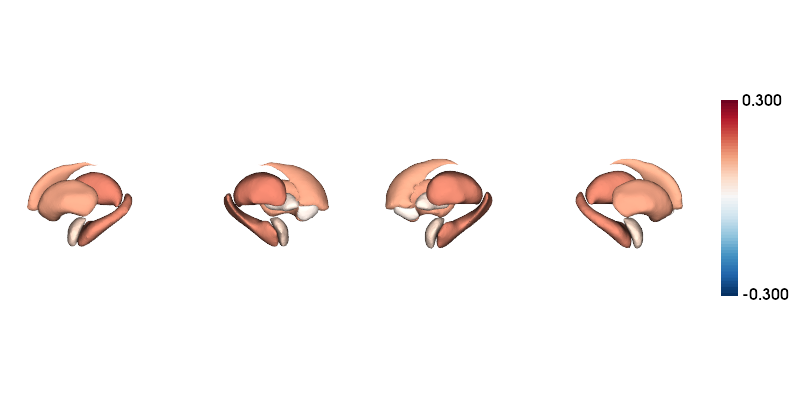

In [12]:
# ── Subcortical FC mean strength ───────────────────────────────────────────────
# fc_sctx shape: (14, 68) — 14 subcortical regions (no ventricles)
# ventricles=False tells plot_subcortical to expect 14 values instead of 16
sctx_fc_strength = fc_sctx.mean(axis=1)
print('Subcortical FC strength:', dict(zip(fc_sctx_labels, sctx_fc_strength.round(3))))

plot_subcortical(
    array_name=sctx_fc_strength,
    ventricles=False,
    size=(800, 400),
    cmap='RdBu_r',
    color_bar=True,
    color_range=(-0.3, 0.3),
    screenshot=True,
    filename='subcortical_fc_strength.png',
)
display(Image('subcortical_fc_strength.png'))

Subcortical SC strength: {np.str_('Laccumb'): np.float64(1.46), np.str_('Lamyg'): np.float64(1.898), np.str_('Lcaud'): np.float64(3.194), np.str_('Lhippo'): np.float64(2.388), np.str_('Lpal'): np.float64(1.734), np.str_('Lput'): np.float64(4.704), np.str_('Lthal'): np.float64(4.882), np.str_('Raccumb'): np.float64(1.479), np.str_('Ramyg'): np.float64(1.473), np.str_('Rcaud'): np.float64(3.203), np.str_('Rhippo'): np.float64(2.603), np.str_('Rpal'): np.float64(2.235), np.str_('Rput'): np.float64(4.412), np.str_('Rthal'): np.float64(4.57)}


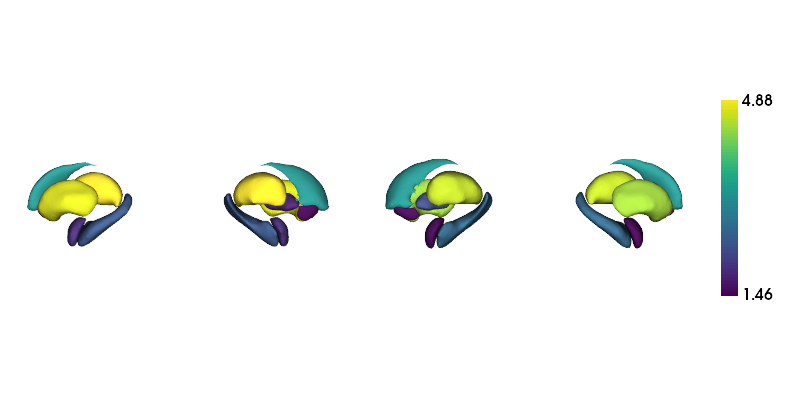

In [13]:
# ── Subcortical SC mean strength (from sc_sctx cross-block) ───────────────────
# Show mean SC streamline strength per subcortical region to cortex
# sc_sctx shape: (14, 68) → mean across 68 cortical targets
sctx_sc_strength = sc_sctx.mean(axis=1)
print('Subcortical SC strength:', dict(zip(sc_sctx_labels, sctx_sc_strength.round(3))))

plot_subcortical(
    array_name=sctx_sc_strength,
    ventricles=False,
    size=(800, 400),
    cmap='viridis',
    color_bar=True,
    color_range=(sctx_sc_strength.min(), sctx_sc_strength.max()),
    screenshot=True,
    filename='subcortical_sc_strength.png',
)
display(Image('subcortical_sc_strength.png'))